Accuracy: 0.8101
Classification Error: 0.1899


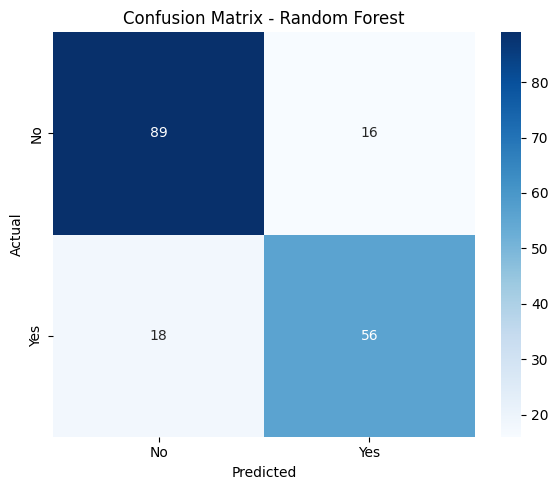

C:\Users\PC\AppData\Local\Temp\ipykernel_9964\3620177251.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette="Blues_r")


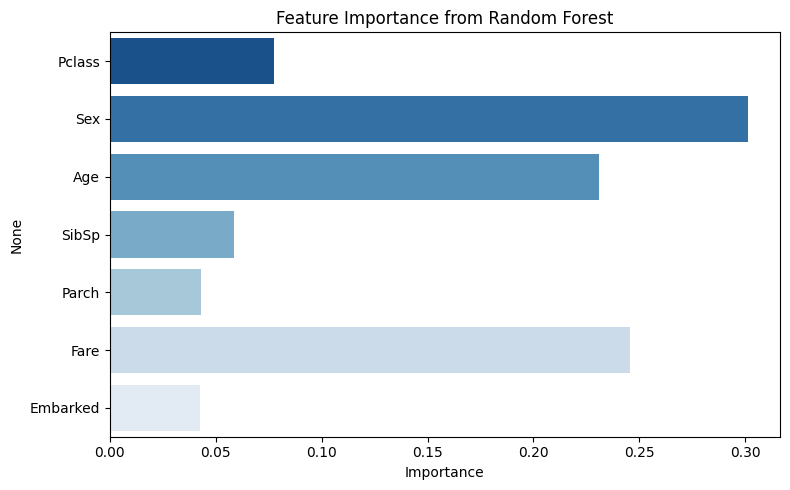

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv("titanic_clean.csv")
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Tách train/test
X_train_base, X_test, y_train_base, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện 100 mô hình RF với bootstrap sampling
errors = []
all_predictions = []

for i in range(100):
    idx = np.random.choice(len(X_train_base), size=len(X_train_base), replace=True)
    X_boot = X_train_base.iloc[idx]
    y_boot = y_train_base.iloc[idx]

    model = RandomForestClassifier(n_estimators=100, random_state=i)
    model.fit(X_boot, y_boot)

    y_pred = model.predict(X_test)
    all_predictions.append(y_pred)
    errors.append(1 - accuracy_score(y_test, y_pred))

# Trung bình dự đoán qua 100 mô hình
final_pred = np.round(np.mean(np.array(all_predictions), axis=0)).astype(int)

# Tính Accuracy & Error
final_acc = accuracy_score(y_test, final_pred)
final_err = 1 - final_acc
print(f"Accuracy: {final_acc:.4f}")
print(f"Classification Error: {final_err:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

# Feature importance
importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette="Blues_r")
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Đọc dữ liệu đã clean
df = pd.read_csv("titanic_clean.csv")
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Tách train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Huấn luyện Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_err = 1 - rf_acc

# --- Huấn luyện Decision Tree ---
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_err = 1 - dt_acc

# --- Kết quả ---
results = pd.DataFrame({
    "Method": ["RF", "DT"],
    "Accuracy": [rf_acc, dt_acc],
    "Classification Error": [rf_err, dt_err]
})

print(results)


  Method  Accuracy  Classification Error
0     RF  0.810056              0.189944
1     DT  0.782123              0.217877
